In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')

df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [21]:
# 누락 값을 앞데이터를 아래로 채움
df = df.ffill()

In [22]:
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop({'전출지별'}, axis = 1)
df_seoul = df_seoul.rename({'전입지별':'전입지'}, axis=1)
df_seoul = df_seoul.set_index("전입지")
df_seoul

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
대구광역시,-,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
인천광역시,-,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
광주광역시,-,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932
대전광역시,-,-,-,-,-,-,-,-,-,-,...,13515,13632,13819,13900,14080,13440,13403,13453,12619,11815
울산광역시,-,-,-,-,-,-,-,-,-,-,...,5057,4845,4742,5188,5691,5542,6047,5950,5102,4260
세종특별자치시,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,2998,2851,6481,7550,5943,5813
경기도,130149,150313,93333,143234,149045,253705,202276,207722,237684,278411,...,412408,398282,410735,373771,354135,340801,332785,359337,370760,342433


In [23]:
sr_one = df_seoul.loc['경기도']
sr_one.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

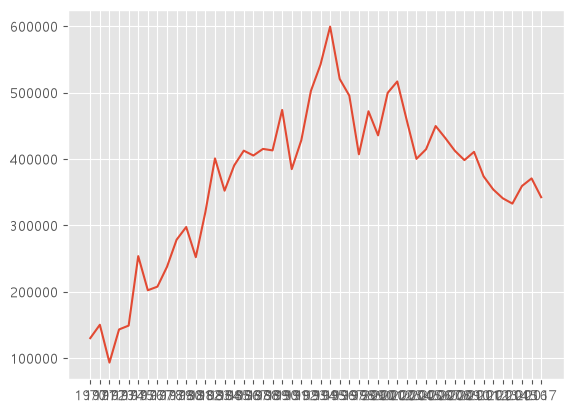

In [24]:
plt.plot(sr_one.index, sr_one.values)

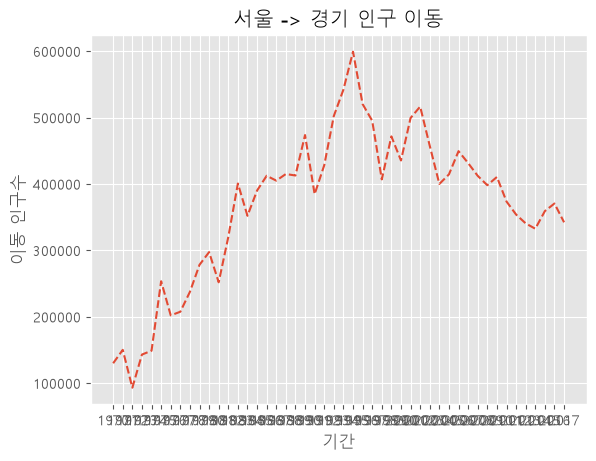

In [25]:
# 차트 제목/축 이름 추가, 선 스타일 지정

plt.plot(sr_one.index, sr_one.values, linestyle='--')
plt.title('서울 -> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.show()

In [26]:
# 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = './data/malgun.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

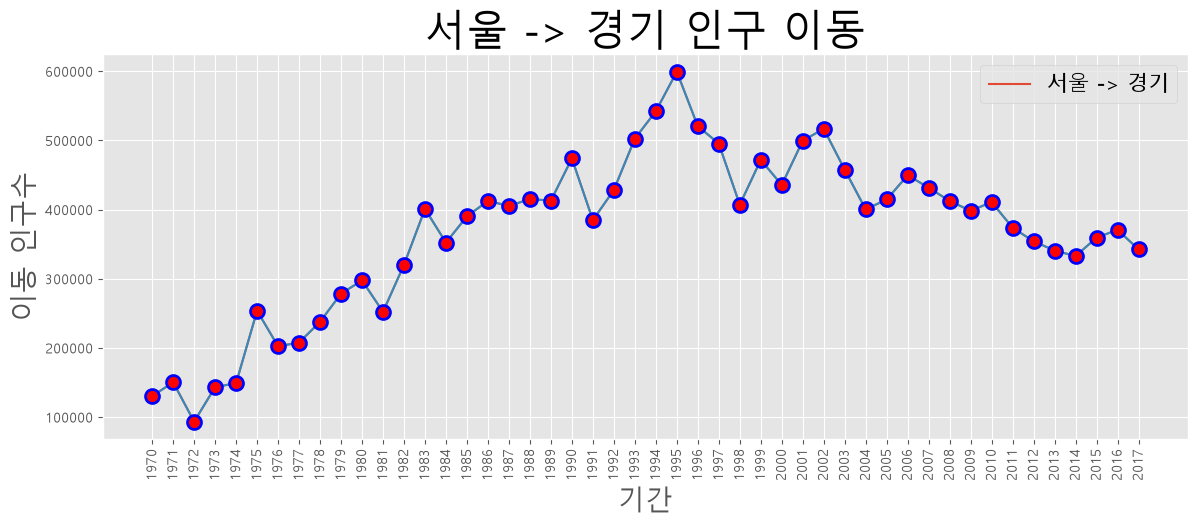

In [27]:
plt.style.use('ggplot')

plt.figure(figsize=(14, 5))

plt.xticks(rotation='vertical')
plt.plot(sr_one.index, sr_one.values)

plt.title('서울 -> 경기 인구 이동', size=30)
plt.xlabel('기간', size=20)
plt.ylabel('이동 인구수', size=20)

plt.plot(sr_one.index, sr_one.values,
        marker='o',
        markerfacecolor='red',
        markeredgecolor='blue',
        markeredgewidth=2,
        markersize=10)

plt.legend(labels=['서울 -> 경기'], loc='best', fontsize=15)
plt.show()

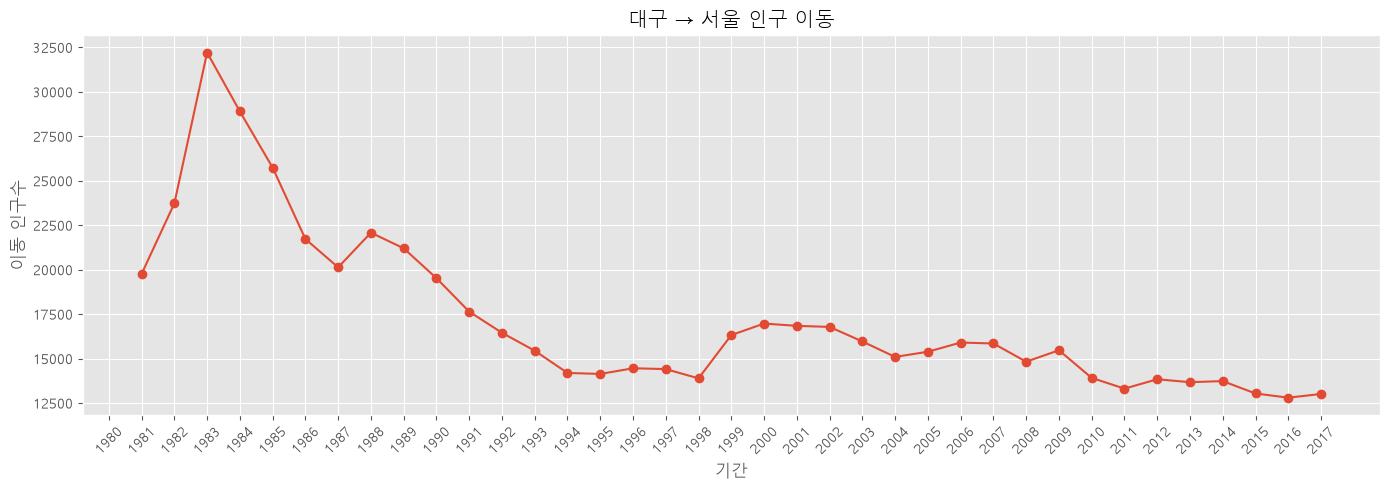

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

mask = (df["전출지별"] == "대구광역시") & (df["전입지별"] != "대구광역시")
df_daegu = df[mask]
df_daegu = df_daegu.drop(["전출지별"], axis=1)
df_daegu = df_daegu.rename({"전입지별": "전입지"}, axis=1)
df_daegu = df_daegu.set_index("전입지")
df_daegu

sr_one = df_daegu.loc["서울특별시"]

# 이동 인구수를 숫자 자료형으로 변환
sr_one = pd.to_numeric(sr_one, errors="coerce")

plt.figure(figsize=(14, 5))
plt.plot(
    sr_one.index,
    sr_one.values,
    marker="o"
)

plt.title("대구 → 서울 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

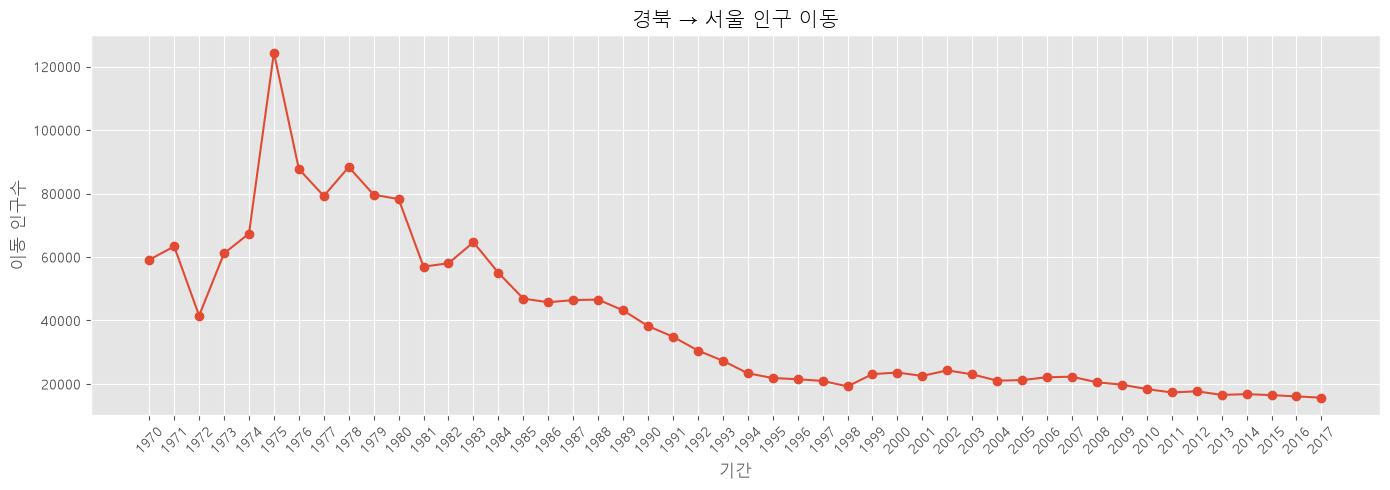

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

mask = (df["전출지별"] == "경상북도") & (df["전입지별"] != "경상북도")
df_kyungbuk = df[mask]
df_kyungbuk = df_kyungbuk.drop(["전출지별"], axis=1)
df_kyungbuk = df_kyungbuk.rename({"전입지별": "전입지"}, axis=1)
df_kyungbuk = df_kyungbuk.set_index("전입지")
df_kyungbuk

sr_one = df_kyungbuk.loc["서울특별시"]

# 이동 인구수를 숫자 자료형으로 변환
sr_one = pd.to_numeric(sr_one, errors="coerce")

plt.figure(figsize=(14, 5))
plt.plot(
    sr_one.index,
    sr_one.values,
    marker="o"
)

plt.title("경북 → 서울 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

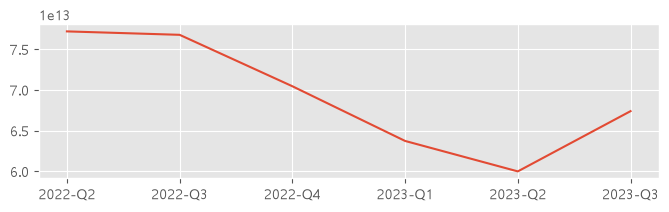

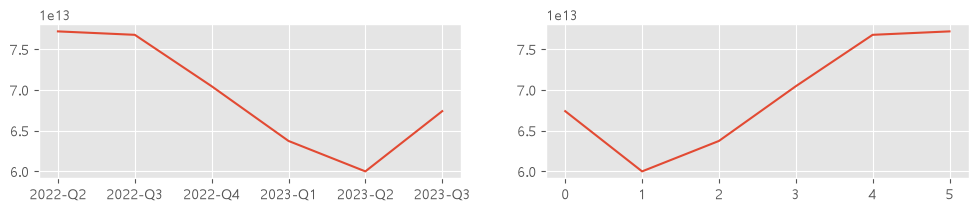

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

samsung_revenue = pd.read_csv('./data/삼성전자_분기별_매출액.csv')
samsung_revenue = samsung_revenue.sort_values('quarter')

fig = plt.figure()
fig,axe = plt.subplots(figsize=(8,2))
axe.plot(samsung_revenue['quarter'], samsung_revenue['value'])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,2))
axes[0].plot(samsung_revenue['quarter'], samsung_revenue['value'])
samsung_revenue['value'].plot(ax=axes[1])
plt.show()


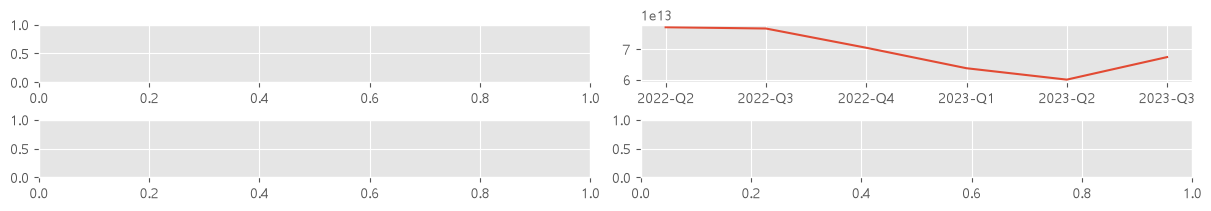

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 2), constrained_layout=True)
axes[0, 1].plot(samsung_revenue['quarter'], samsung_revenue['value'])
plt.show()


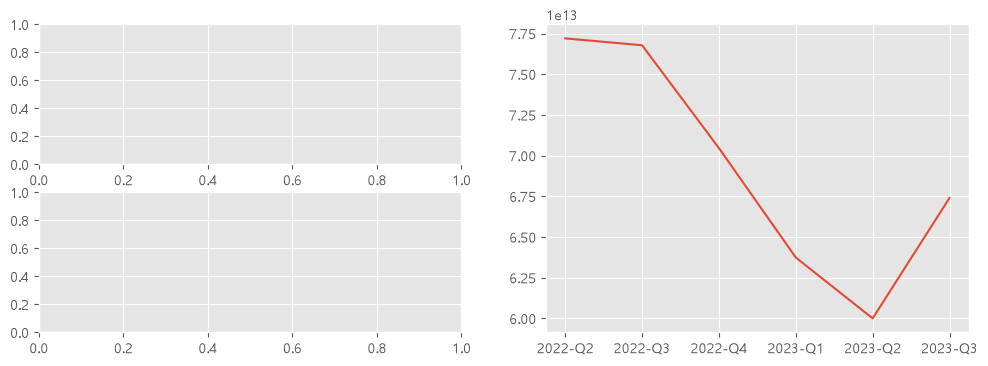

In [32]:
fig, axes = plt.subplot_mosaic([['top_left', 'right'], ['bottom_left', 'right']], figsize=(12,4))
axes['right'].plot(samsung_revenue['quarter'], samsung_revenue['value'])
plt.show()


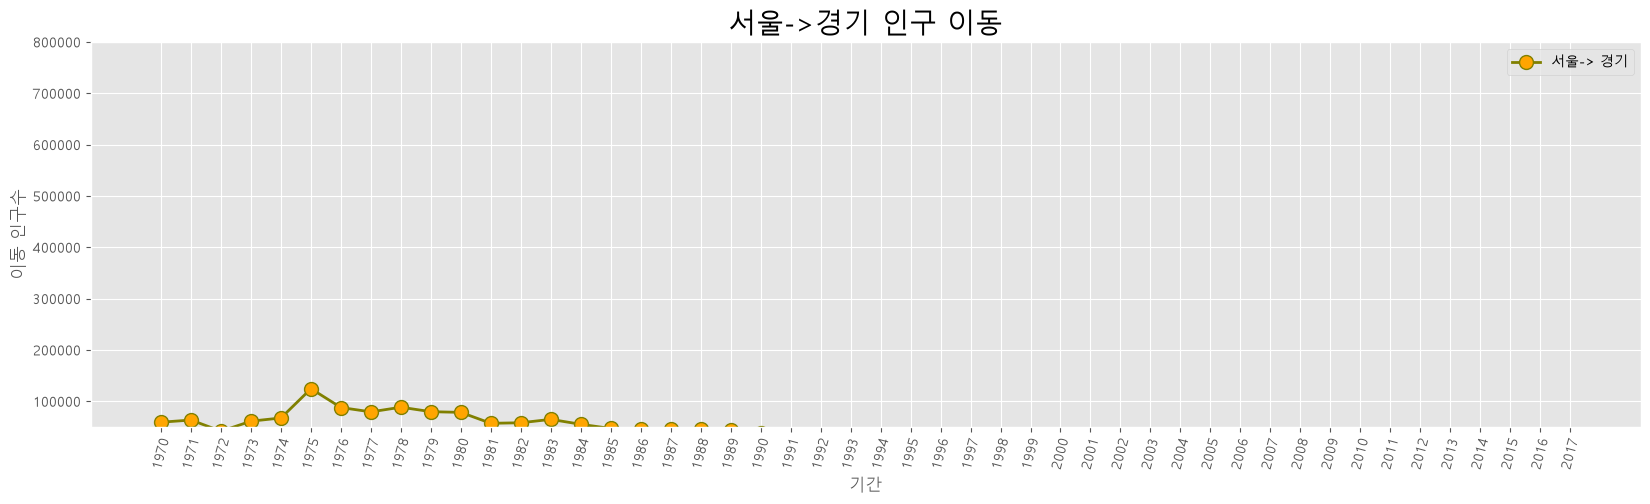

In [36]:


plt.style.use('ggplot')
fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(sr_one, marker='o', markerfacecolor='orange', markersize=10, color='olive', linewidth=2, label='서울-> 경기')
ax.legend(loc='best')
ax.set_ylim(50000, 800000)
ax.set_title('서울->경기 인구 이동', size=20)
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)
ax.set_xticks(sr_one.index)
ax.set_xticklabels(sr_one.index, rotation=75)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

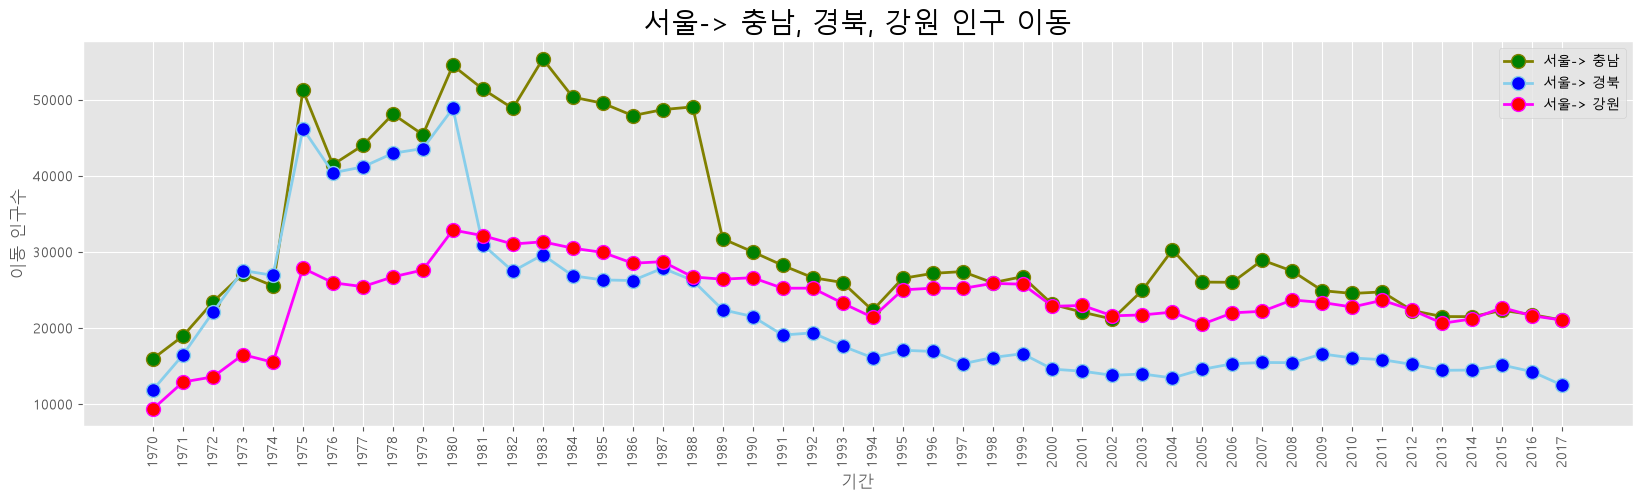

In [41]:
col_years = list(map(str, range(1970, 2018)))
df_3 = df_seoul.loc[['충청남도', '경상북도', '강원도'], col_years]
plt.style.use('ggplot')
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(col_years, df_3.loc['충청남도',:], marker='o', markerfacecolor='green', markersize=10, color='olive', linewidth=2, label='서울-> 충남')
ax.plot(col_years, df_3.loc['경상북도',:], marker='o', markerfacecolor='blue', markersize=10, color='skyblue', linewidth=2, label='서울-> 경북')
ax.plot(col_years, df_3.loc['강원도',:], marker='o', markerfacecolor='red', markersize=10, color='magenta', linewidth=2, label='서울-> 강원')

ax.legend(loc='best')

ax.set_title('서울-> 충남, 경북, 강원 인구 이동', size=20)

ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

ax.set_xticks(range(len(col_years)))
ax.set_xticklabels(col_years, rotation=90)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

KeyError: '전라남도'

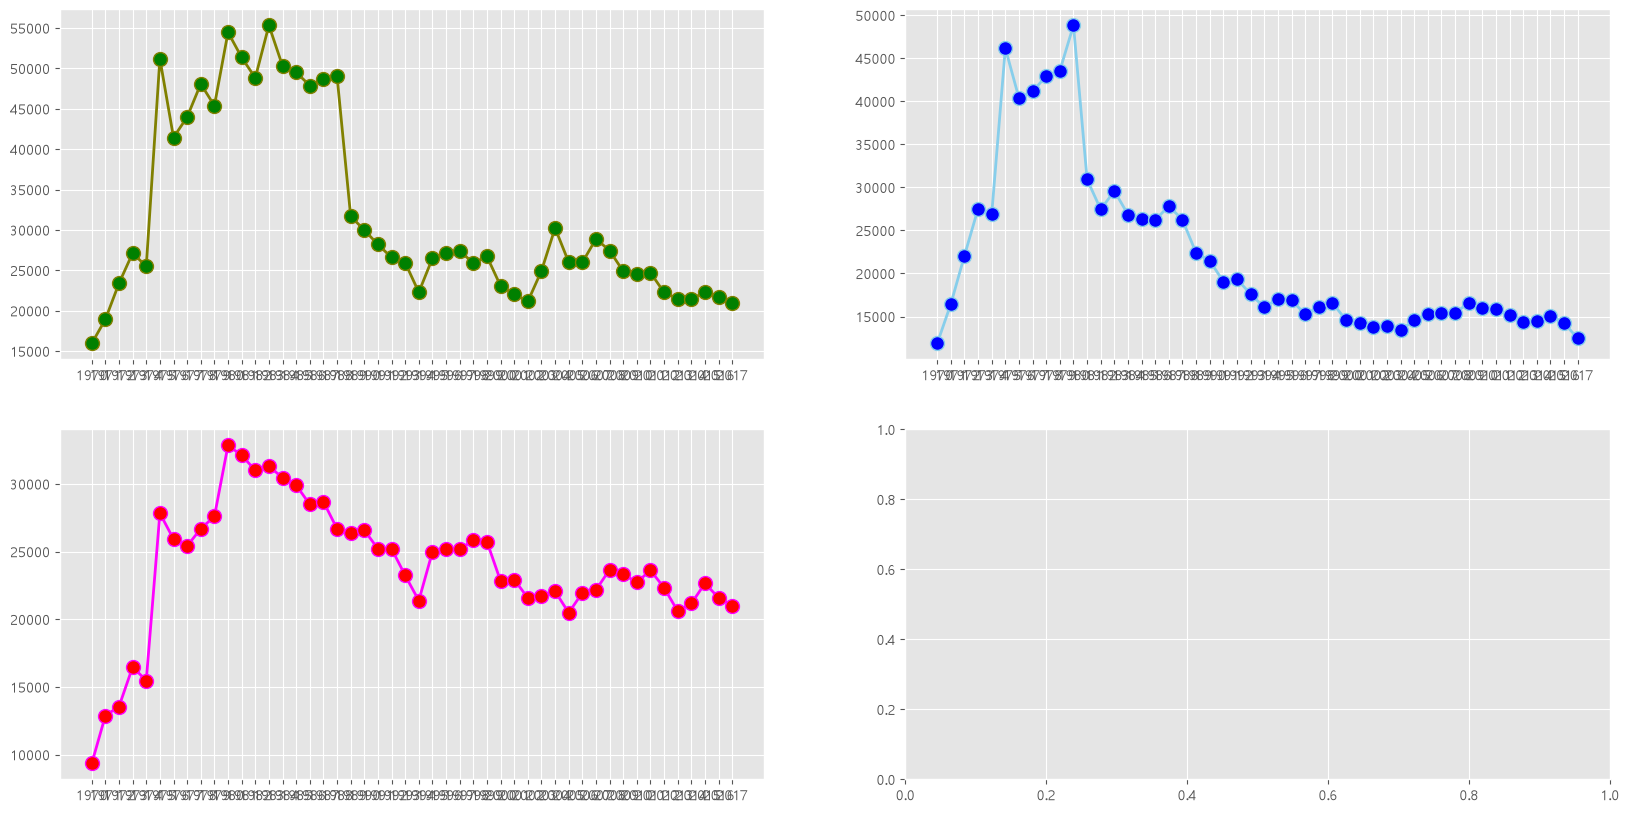

In [43]:
col_years = list(map(str, range(1970, 2018)))

df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.plot(col_years, df_3.loc['충청남도',:], marker='o', markerfacecolor='green', markersize=10, color='olive', linewidth=2, label='서울-> 충남')
ax2.plot(col_years, df_3.loc['경상북도',:], marker='o', markerfacecolor='blue', markersize=10, color='skyblue', linewidth=2, label='서울-> 경북')
ax3.plot(col_years, df_3.loc['강원도',:], marker='o', markerfacecolor='red', markersize=10, color='magenta', linewidth=2, label='서울-> 강원')
ax4.plot(col_years, df_3.loc['전라남도',:], marker='o', markerfacecolor='orange', markersize=10, color='yellow', linewidth=2, label='서울-> 전남')

ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')
ax4.legend(loc='best')

ax1.set_title('서울-> 충남 인구 이동', size=15)
ax2.set_title('서울-> 경북 인구 이동', size=15)
ax3.set_title('서울-> 강원 인구 이동', size=15)
ax4.set_title('서울-> 전남 인구 이동', size=15)

ax1.set_xticks(range(len(col_years)))
ax2.set_xticks(range(len(col_years)))
ax3.set_xticks(range(len(col_years)))
ax4.set_xticks(range(len(col_years)))

ax1.set_xticklabels(col_years, rotation=90)
ax2.set_xticklabels(col_years, rotation=90)
ax3.set_xticklabels(col_years, rotation=90)
ax4.set_xticklabels(col_years, rotation=90)

plt.show()

In [45]:
# Matplotlib 에서 사용할 수 있는 색의 종류
import matplotlib

colors = {}

for name, hex in matplotlib.colors.cnames.items():
    colors[name] = hex

print(colors)

{'aliceblue': '#F0F8FF', 'antiquewhite': '#FAEBD7', 'aqua': '#00FFFF', 'aquamarine': '#7FFFD4', 'azure': '#F0FFFF', 'beige': '#F5F5DC', 'bisque': '#FFE4C4', 'black': '#000000', 'blanchedalmond': '#FFEBCD', 'blue': '#0000FF', 'blueviolet': '#8A2BE2', 'brown': '#A52A2A', 'burlywood': '#DEB887', 'cadetblue': '#5F9EA0', 'chartreuse': '#7FFF00', 'chocolate': '#D2691E', 'coral': '#FF7F50', 'cornflowerblue': '#6495ED', 'cornsilk': '#FFF8DC', 'crimson': '#DC143C', 'cyan': '#00FFFF', 'darkblue': '#00008B', 'darkcyan': '#008B8B', 'darkgoldenrod': '#B8860B', 'darkgray': '#A9A9A9', 'darkgreen': '#006400', 'darkgrey': '#A9A9A9', 'darkkhaki': '#BDB76B', 'darkmagenta': '#8B008B', 'darkolivegreen': '#556B2F', 'darkorange': '#FF8C00', 'darkorchid': '#9932CC', 'darkred': '#8B0000', 'darksalmon': '#E9967A', 'darkseagreen': '#8FBC8F', 'darkslateblue': '#483D8B', 'darkslategray': '#2F4F4F', 'darkslategrey': '#2F4F4F', 'darkturquoise': '#00CED1', 'darkviolet': '#9400D3', 'deeppink': '#FF1493', 'deepskyblue'

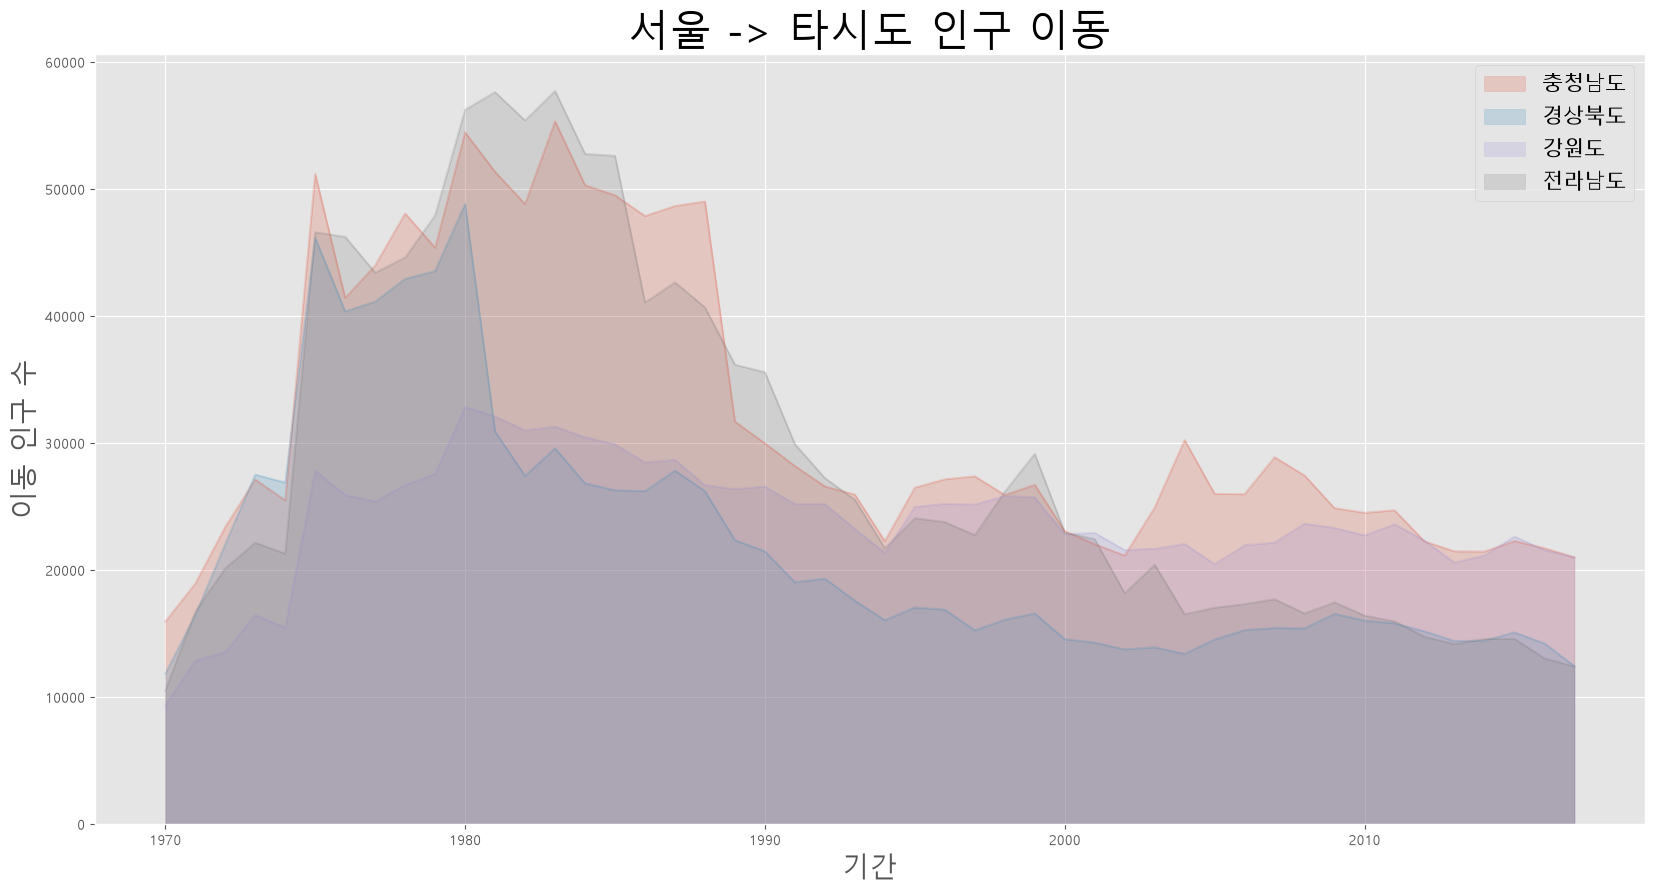

In [ ]:
# 면적 그래프

col_years = list(map(str, range(1970, 2018)))

df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]

df_4 = df_4.astype(int)
df_4 = df_4.transpose()

plt.style.use('ggplot')
df_4.plot(kind='area', stacked=False, alpha=0.2, figsize=(20, 10))

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.legend(loc='best', fontsize=15)
plt.show()


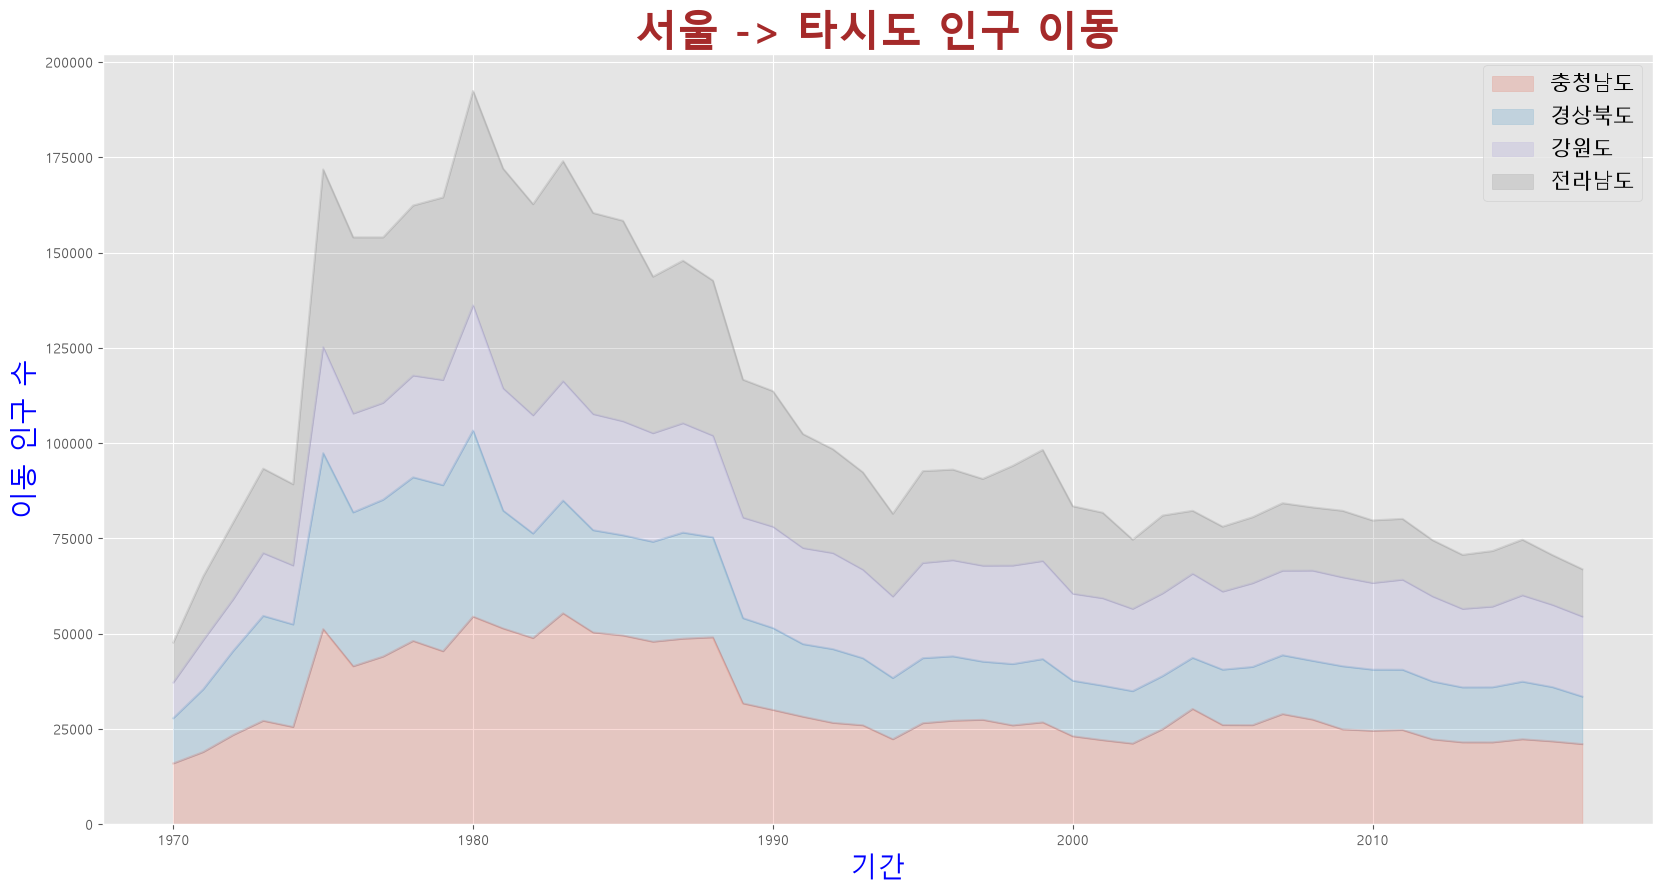

In [49]:
plt.style.use('ggplot')

ax = df_4.plot(kind='area', stacked=True, alpha=0.2, figsize=(20, 10))

plt.title('서울 -> 타시도 인구 이동', size=30, color='brown', weight='bold')
plt.ylabel('이동 인구 수', size=20, color='blue')
plt.xlabel('기간', size=20, color='blue')
plt.legend(loc='best', fontsize=15)
plt.show()

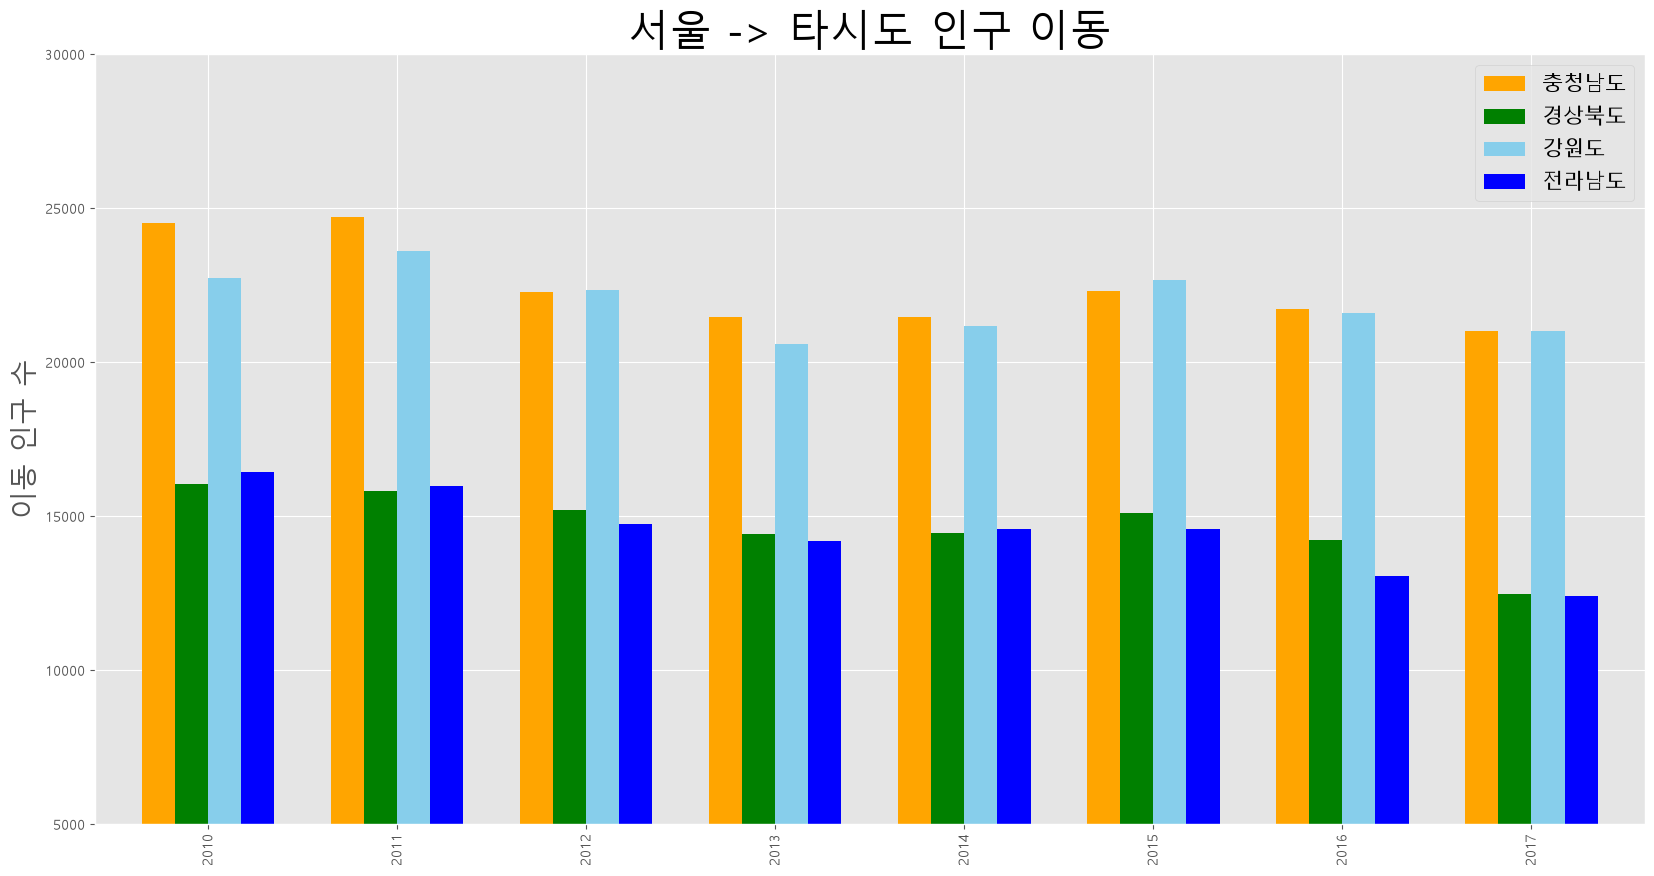

In [52]:
# 막대 그래프

col_years = list(map(str, range(2010, 2018)))

df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]
\
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

df_4.plot(kind='bar', figsize=(20, 10), width=0.7, color=['orange', 'green', 'skyblue', 'blue'])

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.ylim(5000, 30000)
plt.legend(loc='best', fontsize=15)
plt.show()


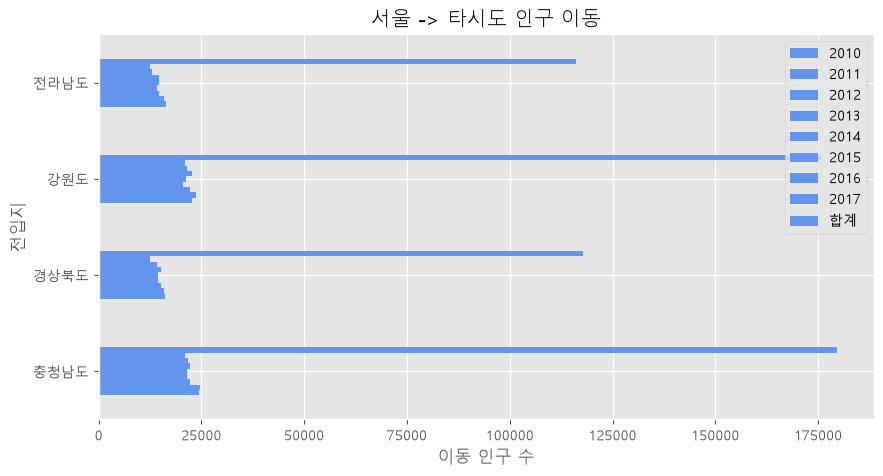

In [53]:
# 막대 그래프

col_years = list(map(str, range(2010, 2018)))

df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]

df_4['합계'] = df_4.sum(axis=1)

df_total = df_4[['합계']].sort_values(by='합계', ascending=True)

plt.style.use('ggplot')


df_4.plot(kind='barh', color='cornflowerblue', width=0.5, figsize=(10, 5))

plt.title('서울 -> 타시도 인구 이동')
plt.ylabel('전입지')
plt.xlabel('이동 인구 수')

plt.show()

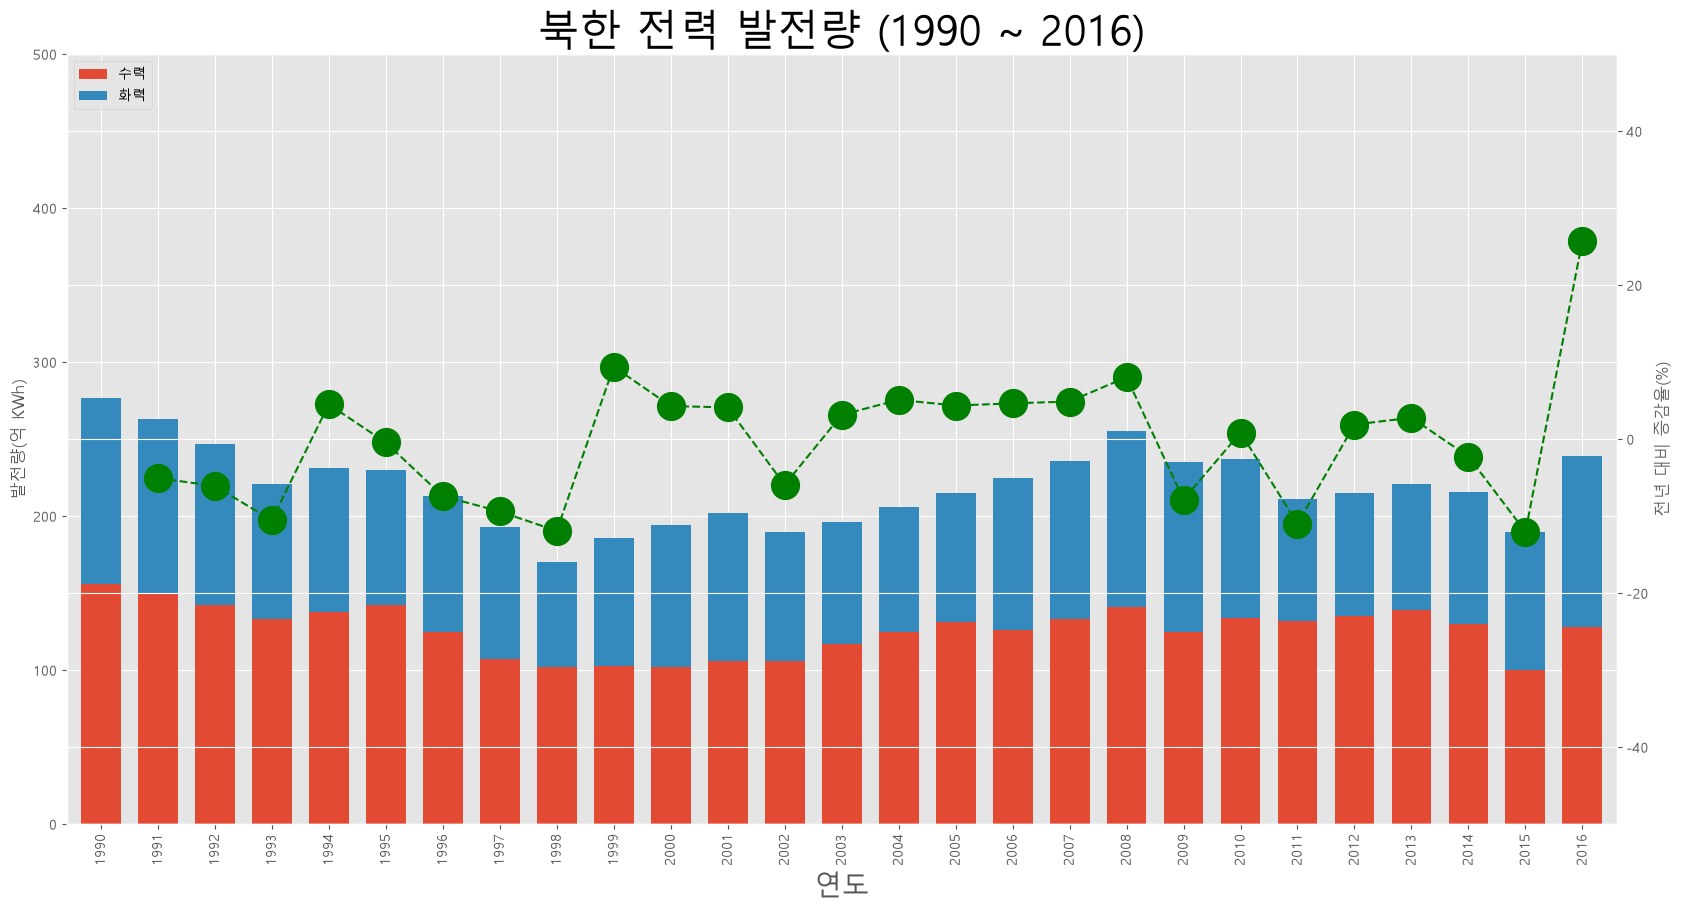

In [55]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"   #폰트파일의 위치
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

plt.style.use('ggplot')   # 스타일 서식 지정
plt.rcParams['axes.unicode_minus']=False   # 마이너스 부호 출력 설정

# Excel 데이터를 데이터프레임 변환 
df = pd.read_excel('./data/남북한발전전력량.xlsx')
df = df.loc[5:9]
df.drop('전력량 (억㎾h)', axis='columns', inplace=True)
df.set_index('발전 전력별', inplace=True)
df = df.T 

# 원자력 열의 "-" 값을 "0"으로 변경하고, 자료형을 실수형으로 변환
for col in df.columns:
    df[col] = df[col].replace("-", "0")
    
df = df.astype(float)

# 증감율(변동률) 계산
df = df.rename(columns={'합계':'총발전량'})
df['총발전량 - 1년'] = df['총발전량'].shift(1)
df['증감율'] = ((df['총발전량'] / df['총발전량 - 1년']) - 1) * 100     

# 2축 그래프 그리기
ax1 = df[['수력','화력']].plot(kind='bar', figsize=(20, 10), width=0.7, stacked=True)  
ax2 = ax1.twinx()
ax2.plot(df.index, df.증감율, ls='--', marker='o', markersize=20, 
         color='green', label='전년대비 증감율(%)')  

ax1.set_ylim(0, 500)
ax2.set_ylim(-50, 50)

ax1.set_xlabel('연도', size=20)
ax1.set_ylabel('발전량(억 KWh)')
ax2.set_ylabel('전년 대비 증감율(%)')

plt.title('북한 전력 발전량 (1990 ~ 2016)', size=30)
ax1.legend(loc='upper left')

plt.show()

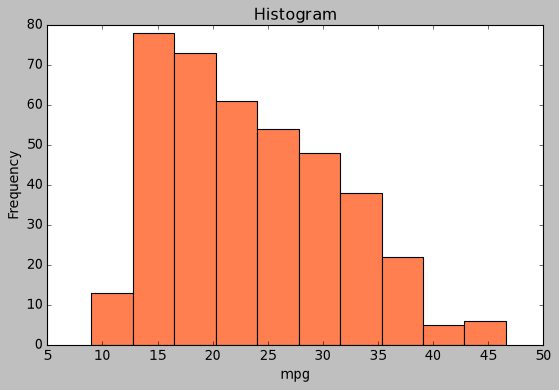

In [56]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('classic')   # 스타일 서식 지정

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 연비(mpg) 열에 대한 히스토그램 그리기
df['mpg'].plot(kind='hist', bins=10, color='coral', figsize=(8, 5))

# 그래프 꾸미기
plt.title('Histogram')
plt.xlabel('mpg')
plt.show()


array([<Axes: title={'center': '1'}, ylabel='Frequency'>,
       <Axes: title={'center': '2'}, ylabel='Frequency'>,
       <Axes: title={'center': '3'}, ylabel='Frequency'>], dtype=object)

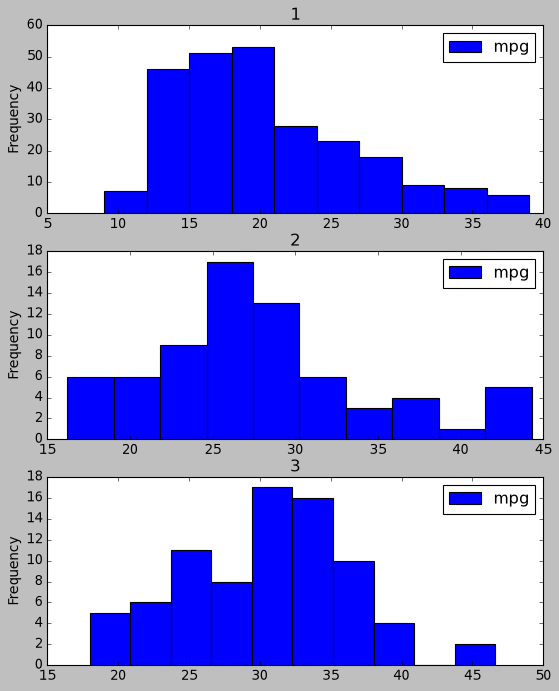

In [58]:
df[['mpg', 'origin']].plot(by=['origin'], kind='hist', figsize=(8, 10))

array([<Axes: title={'center': '(1, 4)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(1, 6)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(1, 8)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(2, 4)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(2, 5)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(2, 6)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(3, 3)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(3, 4)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(3, 6)'}, ylabel='Frequency'>],
      dtype=object)

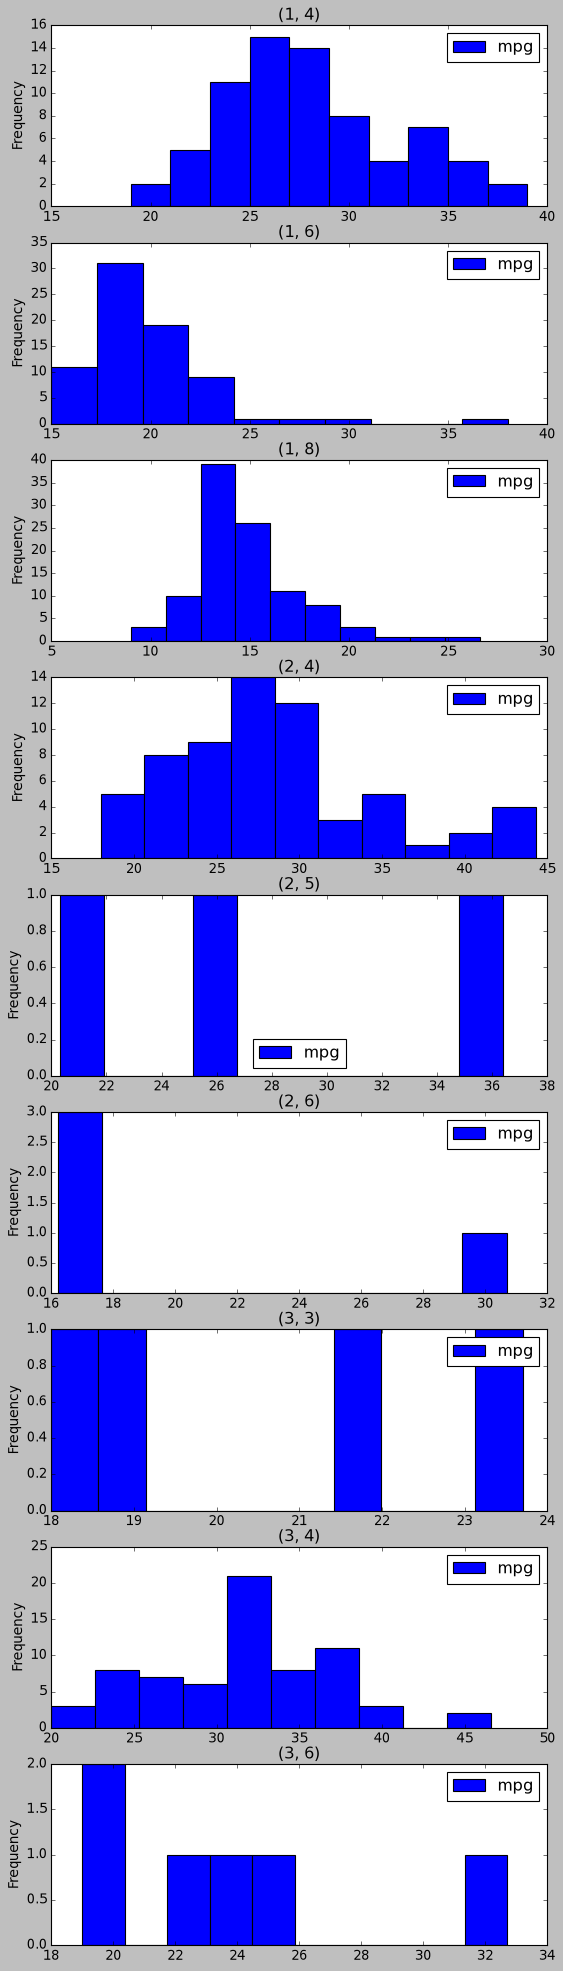

In [59]:
df[['mpg', 'origin', 'cylinders']].plot(by=['origin', 'cylinders'], kind='hist', figsize=(8, 30))

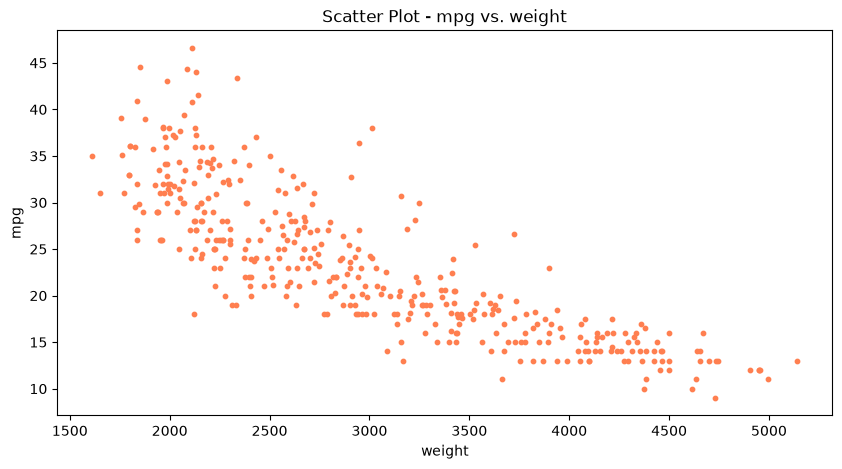

In [60]:
# 산점도
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')   # 스타일 서식 지정

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 연비(mpg)와 차중(weight) 열에 대한 산점도 그리기
df.plot(kind='scatter', x='weight', y='mpg',  c='coral', s=10, figsize=(10, 5))
plt.title('Scatter Plot - mpg vs. weight')
plt.show()

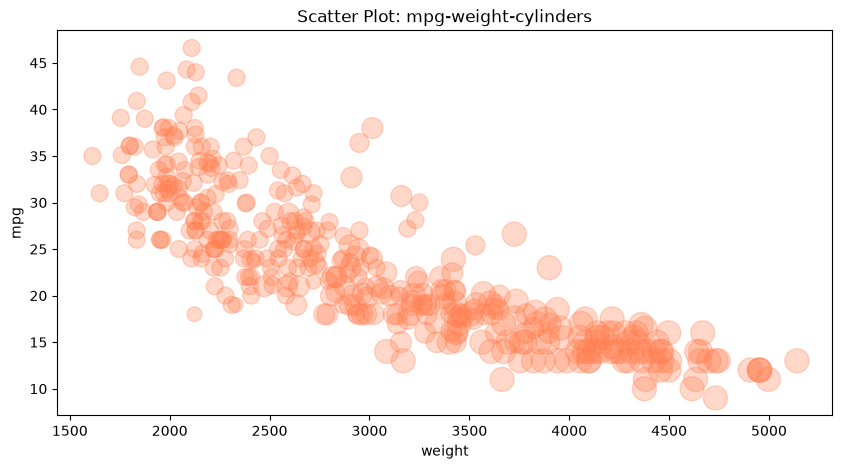

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')   # 스타일 서식 지정

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# cylinders 개수의 상대적 비율을 계산하여 시리즈 생성
cylinders_size = (df['cylinders'] / df['cylinders'].max()) * 300

# 3개의 변수로 산점도 그리기 
df.plot(kind='scatter', x='weight', y='mpg', c='coral', figsize=(10, 5),
        s=cylinders_size, alpha=0.3)
plt.title('Scatter Plot: mpg-weight-cylinders')
plt.show()

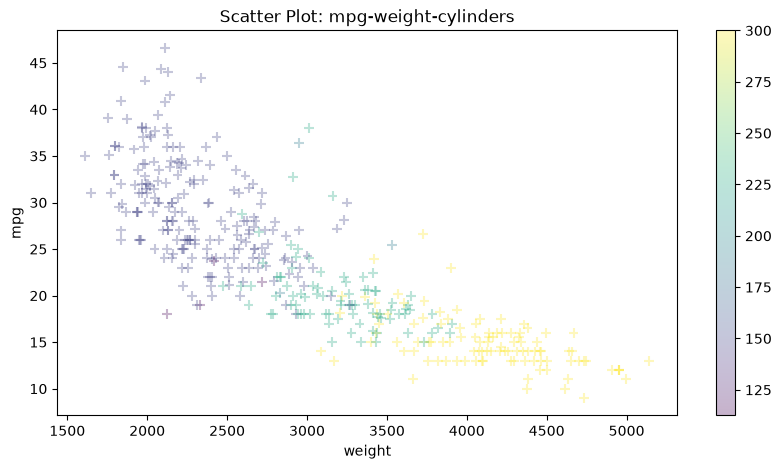

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')   # 스타일 서식 지정

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# cylinders 개수의 상대적 비율을 계산하여 시리즈 생성
cylinders_size = (df['cylinders'] / df['cylinders'].max()) * 300

# 3개의 변수로 산점도 그리기 
df.plot(kind='scatter', x='weight', y='mpg', marker='+', figsize=(10, 5),
        cmap='viridis', c=cylinders_size, s=50, alpha=0.3)
plt.title('Scatter Plot: mpg-weight-cylinders')

plt.savefig("./data/scatter.png")   
plt.savefig("./data/scatter_transparent.png", transparent=True)   

plt.show()

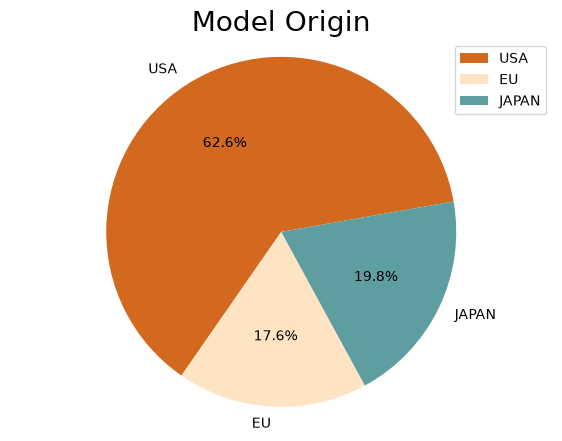

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)

plt.style.use('default')   # 스타일 서식 지정

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 데이터 개수 카운트를 위해 값 1을 가진 열을 추가
df['count'] = 1
df_origin = df.groupby('origin').sum(numeric_only=True)   # origin 열을 기준으로 그룹화, 합계 연산
df_origin.head()   

# 제조국가(origin) 값을 실제 지역명으로 변경
df_origin.index = ['USA', 'EU', 'JAPAN']
df_origin.head()

# 제조국가(origin) 열에 대한 파이 차트 그리기 – count 열 데이터 사용
df_origin['count'].plot(kind='pie', 
                     figsize=(7, 5),
                     autopct='%1.1f%%',                             # 퍼센트 % 표시
                     startangle=10,                                 # 파이 조각을 나누는 시작 위치(각도 표시)
                     colors=['chocolate', 'bisque', 'cadetblue']    # 색상 리스트
                     )

plt.title('Model Origin', size=20)
plt.axis('equal')                                       # 파이 차트의 비율을 같게 (원에 가깝게) 조정
plt.legend(labels=df_origin.index, loc='upper right')   # 범례 표시
plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

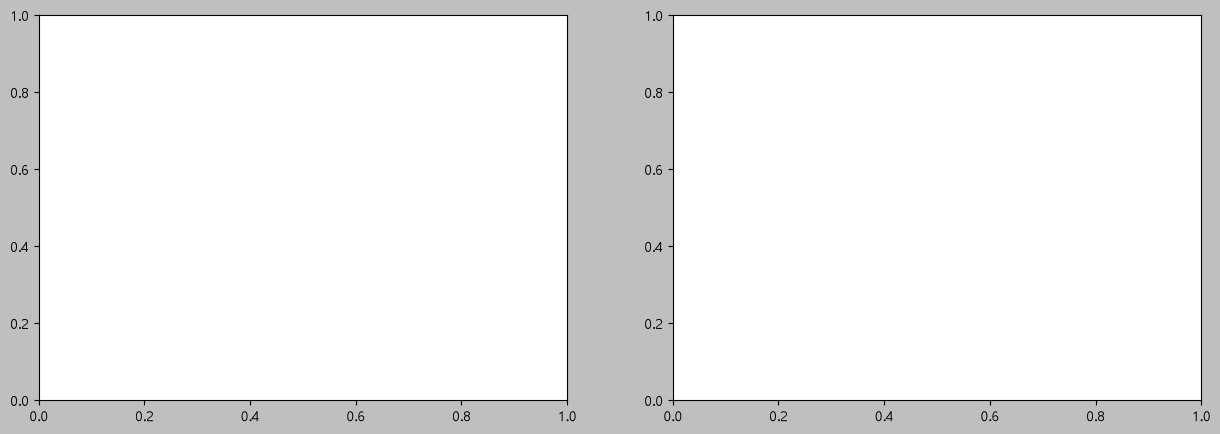

In [3]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"   #폰트파일의 위치
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

plt.style.use('grayscale')            # 스타일 서식 지정
plt.rcParams['axes.unicode_minus']=False   # 마이너스 부호 출력 설정

# read_csv() 함수로 df 생성
df = pd.read_csv('./data/auto-mpg.csv', header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 그래프 객체 생성 (figure에 2개의 서브 플롯을 생성)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))   

# axe 객체에 boxplot 메서드로 그래프 출력
ax1.boxplot(x=[df[df['origin']==1]['mpg'],
               df[df['origin']==2]['mpg'],
               df[df['origin']==3]['mpg']], 
               labels=['USA', 'EU', 'JAPAN'])

ax2.boxplot(x=[df[df['origin']==1]['mpg'],
               df[df['origin']==2]['mpg'],
               df[df['origin']==3]['mpg']], 
               labels=['USA', 'EU', 'JAPAN'],
               vert=False)

ax1.set_title('제조국가별 연비 분포(수직 박스 플롯)')
ax2.set_title('제조국가별 연비 분포(수평 박스 플롯)')

plt.show()

# 판다스 plot 메서드 활용 - 원산지 제조국가별 구분
df.plot(kind='box', column=['mpg', 'weight'], by=['origin'], figsize=(15, 5));

# 판다스 plot 메서드 활용 - 색상 지정, 방향 설정
color = {
    "boxes": "SeaGreen",
    "whiskers": "Olive",
    "medians": "Teal",
    "caps": "SlateGray",
}

df.plot(kind='box', column=['mpg'], by=['origin'], figsize=(15, 5), 
        color=color, sym="r+", vert=False);